In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd

In [2]:
# 데이터 로드
df = pd.read_csv('data/CARD_SUBWAY_MONTH_202605.csv', index_col=False)
df.head()

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
0,20260501,5호선,방이,5527,5357,20260504
1,20260501,5호선,둔촌동,10441,9979,20260504
2,20260501,5호선,상일동,10541,9932,20260504
3,20260501,5호선,고덕,7456,7257,20260504
4,20260501,5호선,명일,6377,6251,20260504


## 2. 데이터 탐색

In [3]:
# 상위 5개의 데이터를 조회
df.head()

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
0,20260501,5호선,방이,5527,5357,20260504
1,20260501,5호선,둔촌동,10441,9979,20260504
2,20260501,5호선,상일동,10541,9932,20260504
3,20260501,5호선,고덕,7456,7257,20260504
4,20260501,5호선,명일,6377,6251,20260504


In [4]:
# 데이터프레임의 형태를 확인
df.shape

(19131, 6)

In [5]:
# 하위 데이터 10개를 조회
df.tail(10)

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
19121,20260531,8호선,문정,7350,7431,20260603
19122,20260531,8호선,장지,10401,9980,20260603
19123,20260531,8호선,복정,5988,5340,20260603
19124,20260531,8호선,산성,3611,3915,20260603
19125,20260531,8호선,남한산성입구(성남법원.검찰청),6905,6413,20260603
19126,20260531,8호선,단대오거리,6782,6559,20260603
19127,20260531,8호선,신흥,3732,3895,20260603
19128,20260531,8호선,수진,4223,3812,20260603
19129,20260531,8호선,모란,3406,2806,20260603
19130,20260531,8호선,남위례,4515,4530,20260603


In [6]:
# 데이터의 사분위수, 표준편차, 분산 등 통계지표를 조회
df.describe()

,사용일자,승차총승객수,하차총승객수,등록일자
count,1.913100e+04,19131.000000,19131.000000,1.913100e+04
mean,2.026052e+07,11811.350740,11759.563640,2.026053e+07
std,8.944833e+00,11836.994181,12011.261965,2.614125e+01
min,2.026050e+07,1.000000,0.000000,2.026050e+07
25%,2.026051e+07,4125.000000,4022.000000,2.026051e+07
50%,2.026052e+07,8396.000000,8135.000000,2.026052e+07
75%,2.026052e+07,15701.500000,15507.500000,2.026053e+07
max,2.026053e+07,101927.000000,115875.000000,2.026060e+07


In [7]:
# 데이터의 결측치등을 조회
df.isna().sum()

사용일자      0
노선명       0
역명        0
승차총승객수    0
하차총승객수    0
등록일자      0
dtype: int64

In [8]:
# 데이터의 타입, 데이터 갯수 등 조회
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19131 entries, 0 to 19130
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   사용일자    19131 non-null  int64 
 1   노선명     19131 non-null  object
 2   역명      19131 non-null  object
 3   승차총승객수  19131 non-null  int64 
 4   하차총승객수  19131 non-null  int64 
 5   등록일자    19131 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 896.9+ KB


In [9]:
df['역명'].nunique()  # 528
df['역명'].unique()

array(['방이', '둔촌동', '상일동', '고덕', '명일', '굽은다리(강동구민회관앞)', '길동', '강동',
       '천호(풍납토성)', '광나루(장신대)', '아차산(어린이대공원후문)', '군자(능동)', '장한평', '답십리',
       '마장', '왕십리(성동구청)', '행당', '신금호', '청구', '동대문역사문화공원(DDP)', '을지로4가',
       '종로3가', '광화문(세종문화회관)', '서대문', '충정로(경기대입구)', '애오개', '공덕', '마포',
       '여의나루', '여의도', '신길', '영등포시장', '영등포구청', '양평', '오목교(목동운동장앞)', '목동',
       '신정(은행정)', '까치산', '화곡', '우장산', '발산', '마곡', '송정', '김포공항', '개화산',
       '방화', '남태령', '사당', '총신대입구(이수)', '동작(현충원)', '이촌(국립중앙박물관)', '신용산',
       '삼각지(전쟁기념관)', '숙대입구(갈월)', '서울역', '회현(남대문시장)', '명동', '충무로', '동대문',
       '혜화', '한성대입구(삼선교)', '성신여대입구(돈암)', '길음', '미아사거리', '미아(서울사이버대학)',
       '수유(강북구청)', '쌍문', '창동', '노원', '상계', '한국항공대', '불암산', '오금', '경찰병원',
       '가락시장', '수서', '일원', '대청', '학여울', '대치', '도곡', '매봉', '양재(서초구청)',
       '남부터미널(예술의전당)', '교대(법원.검찰청)', '고속터미널', '잠원', '신사', '압구정', '옥수',
       '금호', '약수', '동대입구', '을지로3가', '안국', '경복궁(정부서울청사)', '독립문', '무악재',
       '홍제', '녹번', '불광', '연신내', '구파발', '지축', '용두(동대문구청)', '신정네거리', '양천구청'

In [10]:
# '범주형' - value_counts()
df['역명'].value_counts()

역명
서울역      155
공덕       124
김포공항     124
홍대입구      93
고속터미널     93
        ... 
남춘천       31
김유정       31
강촌        31
백양리       31
개롱        31
Name: count, Length: 528, dtype: int64

## 3. 정렬

In [11]:
# '승차총승객수' 기준으로 정렬
df.sort_values(by = '승차총승객수', ascending = False).head()

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
118,20260501,2호선,홍대입구,101927,115875,20260504
8668,20260515,2호선,잠실(송파구청),100436,98646,20260518
682,20260502,2호선,홍대입구,100394,111108,20260505
8674,20260515,2호선,강남,98157,96835,20260518
13541,20260522,1호선,서울역,97514,98036,20260525


## 4. 선택

In [13]:
# '사용일자' 컬럼을 인덱스로 지정하여 df2 객체를 생성
df2 = df.set_index('사용일자')
df2

,노선명,역명,승차총승객수,하차총승객수,등록일자
사용일자,,,,,
20260501,5호선,방이,5527,5357,20260504
20260501,5호선,둔촌동,10441,9979,20260504
20260501,5호선,상일동,10541,9932,20260504
20260501,5호선,고덕,7456,7257,20260504
20260501,5호선,명일,6377,6251,20260504
...,...,...,...,...,...
20260531,8호선,단대오거리,6782,6559,20260603
20260531,8호선,신흥,3732,3895,20260603
20260531,8호선,수진,4223,3812,20260603


In [14]:
df2.head(3)

,노선명,역명,승차총승객수,하차총승객수,등록일자
사용일자,,,,,
20260501,5호선,방이,5527,5357,20260504
20260501,5호선,둔촌동,10441,9979,20260504
20260501,5호선,상일동,10541,9932,20260504


In [25]:
# 인덱스 검색 : loc, iloc
df2.iloc[1]                     # 인덱스 기준 몇번째 데이터인지 기준 접근

노선명            5호선
역명             둔촌동
승차총승객수       10441
하차총승객수        9979
등록일자      20260504
Name: 20260501, dtype: object

In [26]:
df2.loc[20260510]               # 인덱스 값을 기준으로 접근

,노선명,역명,승차총승객수,하차총승객수,등록일자
사용일자,,,,,
20260510,7호선,태릉입구,6549,6519,20260513
20260510,5호선,신길,3197,3374,20260513
20260510,9호선,양천향교,5221,5473,20260513
20260510,9호선,가양,13415,13294,20260513
20260510,9호선,증미,3114,3300,20260513
...,...,...,...,...,...
20260510,중앙선,양평,3155,2873,20260513
20260510,중앙선,원덕,479,373,20260513
20260510,중앙선,용문,4829,4286,20260513


In [27]:
# 일반 데이터 검색 : 팬시, 불린, query
# '노선명' 컬럼의 '2호선' 데이터 검색
df[df['노선명'] == '2호선']             # boolean indexing

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
107,20260501,2호선,용두(동대문구청),1980,1746,20260504
108,20260501,2호선,신정네거리,7710,7364,20260504
109,20260501,2호선,양천구청,4845,4751,20260504
110,20260501,2호선,도림천,814,803,20260504
111,20260501,2호선,신설동,3984,3453,20260504
...,...,...,...,...,...,...
18911,20260531,2호선,신설동,3960,3664,20260603
18912,20260531,2호선,도림천,910,1127,20260603
18913,20260531,2호선,양천구청,3858,3948,20260603
18914,20260531,2호선,신정네거리,6203,6115,20260603


In [32]:
# query
query_exp = "노선명 == '2호선'"
df2.query(query_exp).count()

노선명       1550
역명        1550
승차총승객수    1550
하차총승객수    1550
등록일자      1550
dtype: int64

In [33]:
# '승차총승객수'이 50000명 이상인 '역명'조회

# boolean
df2[df2['승차총승객수'] >= 50000]

,노선명,역명,승차총승객수,하차총승객수,등록일자
사용일자,,,,,
20260501,3호선,고속터미널,68049,73276,20260504
20260501,2호선,홍대입구,101927,115875,20260504
20260501,2호선,강남,56904,56781,20260504
20260501,2호선,잠실(송파구청),91516,89802,20260504
20260501,2호선,성수,79123,95673,20260504
...,...,...,...,...,...
20260531,경부선,용산,50244,48334,20260603
20260531,1호선,서울역,58621,58856,20260603
20260531,2호선,잠실(송파구청),62708,58573,20260603


In [35]:
# query
query_exp = '승차총승객수 >= 50000'
df2.query(query_exp).sort_values(by = '승차총승객수')

,노선명,역명,승차총승객수,하차총승객수,등록일자
사용일자,,,,,
20260504,2호선,신도림,50008,48299,20260507
20260529,경부선,용산,50024,51489,20260601
20260531,경부선,용산,50244,48334,20260603
20260516,2호선,을지로입구,50407,47479,20260519
20260529,2호선,사당,50552,55816,20260601
...,...,...,...,...,...
20260522,1호선,서울역,97514,98036,20260525
20260515,2호선,강남,98157,96835,20260518
20260502,2호선,홍대입구,100394,111108,20260505


In [36]:
# '승차총승객수'이 50000명 이상이고 '역명' 이름이 '강남'인 데이터 조회
df2.query(query_exp).query('역명 == "강남"')

,노선명,역명,승차총승객수,하차총승객수,등록일자
사용일자,,,,,
20260501,2호선,강남,56904,56781,20260504
20260502,2호선,강남,59964,58975,20260505
20260504,2호선,강남,84694,83040,20260507
20260506,2호선,강남,91795,89595,20260509
20260507,2호선,강남,92886,90734,20260510
20260508,2호선,강남,96539,95218,20260511
20260509,2호선,강남,65373,64121,20260512
20260511,2호선,강남,89081,87284,20260514
20260512,2호선,강남,92102,89858,20260515


In [37]:
# '승차총승객수' 컬럼의 최대값
df2['승차총승객수'].max()

101927

In [38]:
# '승차총승객수' 컬럼의 최소값
df2['승차총승객수'].min()

1

In [40]:
# '승차총승객수' 컬럼의 최대값, '하차총승객수' 컬럼의 최소값을 조회
df2.agg({
    '승차총승객수' : 'max',
    '하차총승객수' : 'min'
})

승차총승객수    101927
하차총승객수         0
dtype: int64

In [41]:
# '승차총승객수', '하차총승객수' 컬럼의 최대값을 조회
df2[['승차총승객수', '하차총승객수']].max()

승차총승객수    101927
하차총승객수    115875
dtype: int64

In [42]:
# '승차총승객수', '하차총승객수' 컬럼의 최대값, 최소값, 평균값을 조회
df2[['승차총승객수', '하차총승객수']].agg(['max', 'min', 'mean'])

,승차총승객수,하차총승객수
max,101927.00000,115875.00000
min,1.00000,0.00000
mean,11811.35074,11759.56364


## 5. 삭제

In [48]:
# 행 기준으로 삭제, 0번지 행 삭제, df
df.drop(0)

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
1,20260501,5호선,둔촌동,10441,9979,20260504
2,20260501,5호선,상일동,10541,9932,20260504
3,20260501,5호선,고덕,7456,7257,20260504
4,20260501,5호선,명일,6377,6251,20260504
5,20260501,5호선,굽은다리(강동구민회관앞),8230,7693,20260504
...,...,...,...,...,...,...
19126,20260531,8호선,단대오거리,6782,6559,20260603
19127,20260531,8호선,신흥,3732,3895,20260603
19128,20260531,8호선,수진,4223,3812,20260603
19129,20260531,8호선,모란,3406,2806,20260603


In [51]:
# 행 기준으로 삭제, 3, 5, 7번지 행 삭제, df
df.drop([3, 5, 7]).head(10)

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
0,20260501,5호선,방이,5527,5357,20260504
1,20260501,5호선,둔촌동,10441,9979,20260504
2,20260501,5호선,상일동,10541,9932,20260504
4,20260501,5호선,명일,6377,6251,20260504
6,20260501,5호선,길동,7758,7877,20260504
8,20260501,5호선,천호(풍납토성),21161,19991,20260504
9,20260501,5호선,광나루(장신대),9256,8944,20260504
10,20260501,5호선,아차산(어린이대공원후문),16734,16089,20260504
11,20260501,5호선,군자(능동),10612,11973,20260504
12,20260501,5호선,장한평,13834,13296,20260504


In [52]:
# '등록일자' 컬럼 삭제
df.drop(['등록일자'], axis = 1)

,사용일자,노선명,역명,승차총승객수,하차총승객수
0,20260501,5호선,방이,5527,5357
1,20260501,5호선,둔촌동,10441,9979
2,20260501,5호선,상일동,10541,9932
3,20260501,5호선,고덕,7456,7257
4,20260501,5호선,명일,6377,6251
...,...,...,...,...,...
19126,20260531,8호선,단대오거리,6782,6559
19127,20260531,8호선,신흥,3732,3895
19128,20260531,8호선,수진,4223,3812
19129,20260531,8호선,모란,3406,2806


In [56]:
# '등록일자', '억명' 컬럼 삭제
df.drop(['등록일자', '역명'], axis = 1).head()

,사용일자,노선명,승차총승객수,하차총승객수
0,20260501,5호선,5527,5357
1,20260501,5호선,10441,9979
2,20260501,5호선,10541,9932
3,20260501,5호선,7456,7257
4,20260501,5호선,6377,6251


### 6. 연산

In [58]:
# '승차총승객수' 컬럼에 10을 더하여, '승차총승객수_10' 컬럼을 추가
df['승차총승객수_10'] = df['승차총승객수'] + 10
df

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자,승차총승객수_10
0,20260501,5호선,방이,5527,5357,20260504,5537
1,20260501,5호선,둔촌동,10441,9979,20260504,10451
2,20260501,5호선,상일동,10541,9932,20260504,10551
3,20260501,5호선,고덕,7456,7257,20260504,7466
4,20260501,5호선,명일,6377,6251,20260504,6387
...,...,...,...,...,...,...,...
19126,20260531,8호선,단대오거리,6782,6559,20260603,6792
19127,20260531,8호선,신흥,3732,3895,20260603,3742
19128,20260531,8호선,수진,4223,3812,20260603,4233
19129,20260531,8호선,모란,3406,2806,20260603,3416


In [59]:
# '승차총승객수' - '하차총승객수' 결과를 '승하차총승객수' 컬럼으로 생성하여 추가
df['승하차총승객수'] = df['승차총승객수'] - df['하차총승객수']
df.head()

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자,승차총승객수_10,승하차총승객수
0,20260501,5호선,방이,5527,5357,20260504,5537,170
1,20260501,5호선,둔촌동,10441,9979,20260504,10451,462
2,20260501,5호선,상일동,10541,9932,20260504,10551,609
3,20260501,5호선,고덕,7456,7257,20260504,7466,199
4,20260501,5호선,명일,6377,6251,20260504,6387,126


In [62]:
# '승하차총승객수'의 평균값, 중앙값
df['승하차총승객수'].agg(['mean', 'median'])

mean      51.787099
median    97.000000
Name: 승하차총승객수, dtype: float64

In [63]:
# '노선명' 컬럼의 '2호선' 데이터를 추출하여, df2_rail2 객체 생성
df2_rail2 = df[df['노선명'] == '2호선']
df2_rail2

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자,승차총승객수_10,승하차총승객수
107,20260501,2호선,용두(동대문구청),1980,1746,20260504,1990,234
108,20260501,2호선,신정네거리,7710,7364,20260504,7720,346
109,20260501,2호선,양천구청,4845,4751,20260504,4855,94
110,20260501,2호선,도림천,814,803,20260504,824,11
111,20260501,2호선,신설동,3984,3453,20260504,3994,531
...,...,...,...,...,...,...,...,...
18911,20260531,2호선,신설동,3960,3664,20260603,3970,296
18912,20260531,2호선,도림천,910,1127,20260603,920,-217
18913,20260531,2호선,양천구청,3858,3948,20260603,3868,-90
18914,20260531,2호선,신정네거리,6203,6115,20260603,6213,88


In [64]:
# '노선명' 컬럼의 '2호선' 이고 '역명'이 '강남'인 데이터를 추출하여, df_rail2_gn
df_rail2_gn = df.query('노선명 == "2호선" and 역명 == "강남"')
df_rail2_gn

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자,승차총승객수_10,승하차총승객수
134,20260501,2호선,강남,56904,56781,20260504,56914,123
698,20260502,2호선,강남,59964,58975,20260505,59974,989
1570,20260503,2호선,강남,38314,36857,20260506,38324,1457
1857,20260504,2호선,강남,84694,83040,20260507,84704,1654
2767,20260505,2호선,강남,40017,39003,20260508,40027,1014
3204,20260506,2호선,강남,91795,89595,20260509,91805,2200
4202,20260507,2호선,강남,92886,90734,20260510,92896,2152
4336,20260508,2호선,강남,96539,95218,20260511,96549,1321
5175,20260509,2호선,강남,65373,64121,20260512,65383,1252
5801,20260510,2호선,강남,39906,38418,20260513,39916,1488


### 7. 샘플링

In [70]:
# 상위 10개 데이터를 샘플링
df.sample(10)

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자,승차총승객수_10,승하차총승객수
2459,20260504,3호선,대청,10918,10068,20260507,10928,850
4264,20260507,일산선,백석,11934,12249,20260510,11944,-315
1236,20260503,중앙선,양평,3737,3321,20260506,3747,416
2467,20260504,4호선,노원,24116,27516,20260507,24126,-3400
15823,20260526,경부선,독산,18779,19139,20260529,18789,-360
14187,20260523,5호선,신정(은행정),10868,9217,20260526,10878,1651
18152,20260530,9호선2~3단계,봉은사,17308,18822,20260602,17318,-1514
17759,20260529,6호선,월곡(동덕여대),14432,13547,20260601,14442,885
7541,20260513,5호선,종로3가,17337,17637,20260516,17347,-300
6577,20260511,경춘선,갈매,3066,2774,20260514,3076,292


### 8. 그룹핑
- 범주형 데이터 확인

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19131 entries, 0 to 19130
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   사용일자       19131 non-null  int64 
 1   노선명        19131 non-null  object
 2   역명         19131 non-null  object
 3   승차총승객수     19131 non-null  int64 
 4   하차총승객수     19131 non-null  int64 
 5   등록일자       19131 non-null  int64 
 6   승차총승객수_10  19131 non-null  int64 
 7   승하차총승객수    19131 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 1.2+ MB


In [73]:
# '사용일자', '노선명', '역명' 컬럼의 value_counts()
df[['사용일자', '노선명', '역명']].value_counts()

사용일자      노선명  역명        
20260501  1호선  동대문           1
20260521  경의선  탄현            1
               일산            1
               월롱            1
               운천            1
                            ..
20260511  6호선  이태원           1
               응암            1
               월드컵경기장(성산)    1
               월곡(동덕여대)      1
20260531  중앙선  회기            1
Name: count, Length: 19131, dtype: int64

In [76]:
# '사용일자' 기준으로 그룹핑
df.groupby('사용일자').count().head()

,노선명,역명,승차총승객수,하차총승객수,등록일자,승차총승객수_10,승하차총승객수
사용일자,,,,,,,
20260501,617,617,617,617,617,617,617
20260502,618,618,618,618,618,618,618
20260503,616,616,616,616,616,616,616
20260504,617,617,617,617,617,617,617
20260505,619,619,619,619,619,619,619


### 9. 결측값(NaN) 처리

In [77]:
df.isna().sum()

사용일자         0
노선명          0
역명           0
승차총승객수       0
하차총승객수       0
등록일자         0
승차총승객수_10    0
승하차총승객수      0
dtype: int64

In [78]:
df2['3호선'] = np.nan
df2

,노선명,역명,승차총승객수,하차총승객수,등록일자,3호선
사용일자,,,,,,
20260501,5호선,방이,5527,5357,20260504,NaN
20260501,5호선,둔촌동,10441,9979,20260504,NaN
20260501,5호선,상일동,10541,9932,20260504,NaN
20260501,5호선,고덕,7456,7257,20260504,NaN
20260501,5호선,명일,6377,6251,20260504,NaN
...,...,...,...,...,...,...
20260531,8호선,단대오거리,6782,6559,20260603,NaN
20260531,8호선,신흥,3732,3895,20260603,NaN
20260531,8호선,수진,4223,3812,20260603,NaN


### 12. 시각화(matplotlib)

In [94]:
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트(맑은 고딕) 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

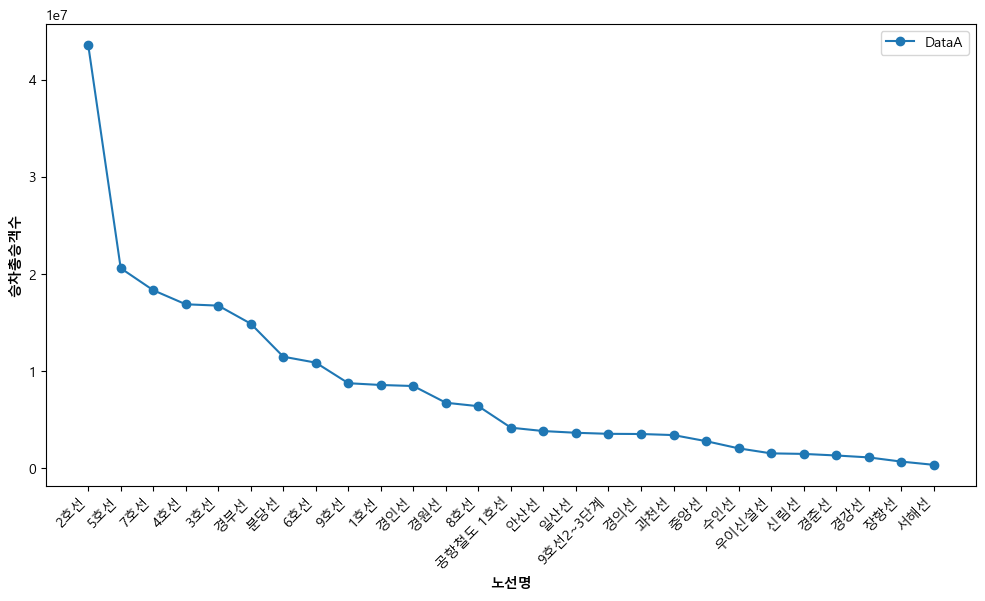

In [102]:
# 노선별 승차총승객수가 많은 노선 리스트 조회
line_sum = df.groupby('노선명')['승차총승객수'].sum().sort_values(ascending = False)
plt.figure(figsize=(12, 6))
plt.xlabel('노선명', fontweight = 'bold')
plt.ylabel('승차총승객수', fontweight = 'bold')
plt.plot(line_sum, marker = 'o', label = 'DataA')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

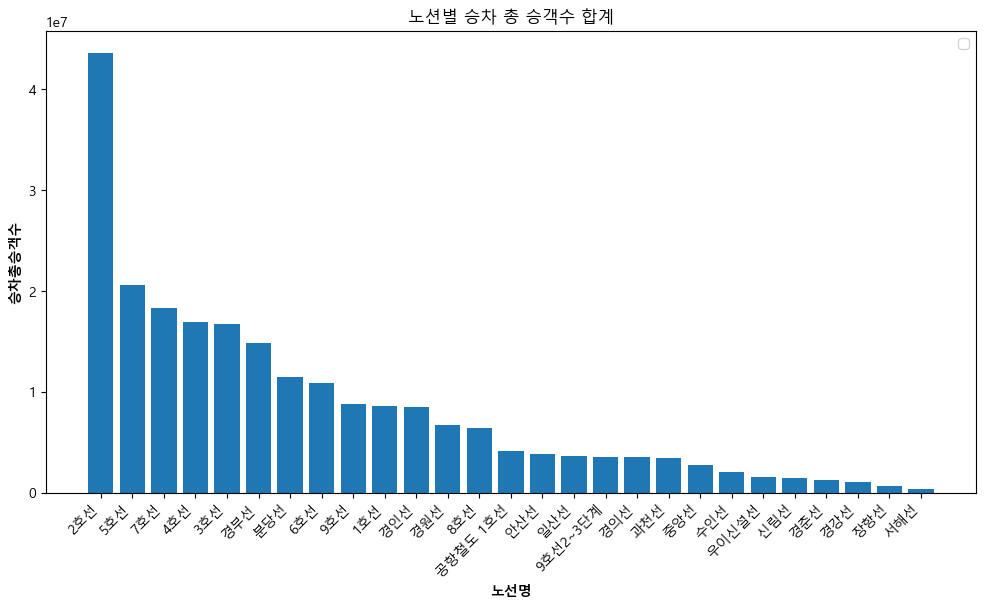

In [108]:
# 막대그래프
plt.figure(figsize=(12, 6))
plt.xlabel('노선명', fontweight = 'bold')
plt.ylabel('승차총승객수', fontweight = 'bold')
plt.title('노션별 승차 총 승객수 합계')
plt.bar(line_sum.index, line_sum.values)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

Text(0.5, 1.0, '승차 역 별 승차 총 승객 수')

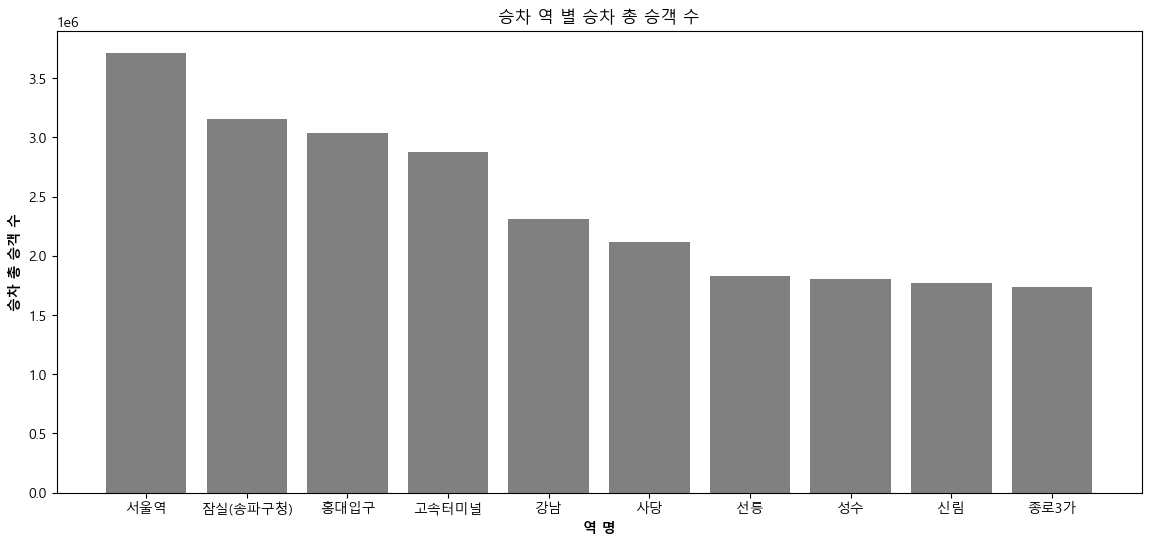

In [117]:
# '승차총승객수' 기준 상위 10개 역 막대 그래프
bars = df.groupby('역명')['승차총승객수'].sum().sort_values(ascending = False).head(10)

plt.figure(figsize = (14,6))
plt.bar(bars.index, bars.values, color = 'gray')
plt.xlabel('역 명', fontweight = 'bold')
plt.ylabel('승차 총 승객 수', fontweight = 'bold')
plt.title('승차 역 별 승차 총 승객 수')